In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from weatherSzegedRegression import X_test

%matplotlib inline

In [9]:
# Email Classification (Work vs Personal)
# subject_formality_score -> Score based on formality of subject line
# sender_relationship_score -> Score representing how familiar the sender is
# email_type -> 0 = Personal, 1 = Work email

In [10]:
data = pd.read_csv("9-email_classification_svm.csv")

In [11]:
data

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1
...,...,...,...
995,-1.903223,-1.109747,1
996,-0.798307,0.851320,0
997,-1.369750,1.022278,0
998,-1.185039,-1.202666,1


In [12]:
data.describe()

,subject_formality_score,sender_relationship_score,email_type
count,1000.000000,1000.000000,1000.000000
mean,-1.009046,-0.006300,0.498000
std,0.654219,1.059501,0.500246
min,-3.532770,-2.218219,0.000000
25%,-1.252867,-1.006076,0.000000
50%,-0.994760,0.439233,0.000000
75%,-0.754839,0.994943,1.000000
max,2.180933,1.699497,1.000000


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [14]:
data.isnull().sum()

subject_formality_score      0
sender_relationship_score    0
email_type                   0
dtype: int64

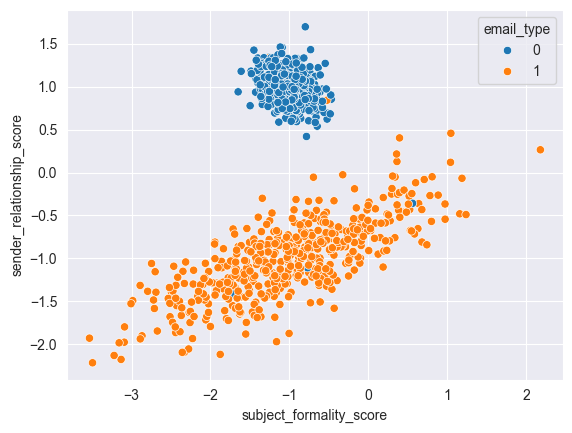

In [17]:
sns.scatterplot(x=data["subject_formality_score"], y=data["sender_relationship_score"], hue=data["email_type"])
plt.show()

In [18]:
data["email_type"].value_counts()

email_type
0    502
1    498
Name: count, dtype: int64

In [19]:
X = data.drop("email_type", axis=1)
y= data["email_type"]

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [29]:
X_train

,subject_formality_score,sender_relationship_score
846,-1.076655,0.943601
969,-1.062554,1.148473
191,-0.904298,1.049447
711,-1.283609,-1.171544
967,-1.097239,1.388281
...,...,...
887,-1.153241,1.241387
645,-0.964472,1.235402
908,-0.862866,1.110327
757,-1.124572,0.967717


In [30]:
from sklearn.svm import SVC

In [39]:
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
svc = SVC(kernel="linear")

In [40]:
svc.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [41]:
svc.coef_

array([[ 0.60318833, -1.91645213]])

In [42]:
y_pred = svc.predict(X_test)

In [43]:
from sklearn.metrics import classification_report, confusion_matrix

In [44]:
print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       117
           1       1.00      0.99      1.00       133

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

[[117   0]
 [  1 132]]


In [47]:
rbf = SVC(kernel="rbf")
rbf.fit(X_train, y_train)
y_pred = svc.predict(X_test)

print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       117
           1       1.00      0.99      1.00       133

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

[[117   0]
 [  1 132]]


data is so simple, kernel change won't mean anything. let's try with a more complex data

In [48]:
data = pd.read_csv("9-loan_risk_svm.csv")

In [50]:
# Bank Loan Risk Classification
# credit_score_fluctuation -> Deviation from customer's average credit score
# recent_transaction_volume -> Volume of recent transactions in past 3 months (scaled)
# loan_risk -> 0 = Low risk, 1 = High risk

In [49]:
data

,credit_score_fluctuation,recent_transaction_volume,loan_risk
0,-1.439860,1.283010,1
1,-0.276571,-1.232382,0
2,1.312047,0.955097,1
3,1.020706,0.089485,0
4,1.513729,0.580520,1
...,...,...,...
995,-0.703085,0.760777,1
996,1.042496,-1.257339,0
997,-0.187788,1.261660,1
998,-0.661871,-0.540731,0


In [51]:
data.describe()

,credit_score_fluctuation,recent_transaction_volume,loan_risk
count,1000.000000,1000.000000,1000.000000
mean,-0.024200,-0.018748,0.504000
std,1.257080,1.222329,0.500234
min,-3.562160,-2.641815,0.000000
25%,-1.001007,-0.995190,0.000000
50%,-0.105200,-0.142727,1.000000
75%,1.007451,0.964210,1.000000
max,2.984892,3.338639,1.000000


In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   credit_score_fluctuation   1000 non-null   float64
 1   recent_transaction_volume  1000 non-null   float64
 2   loan_risk                  1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [53]:
data.isnull().sum()

credit_score_fluctuation     0
recent_transaction_volume    0
loan_risk                    0
dtype: int64

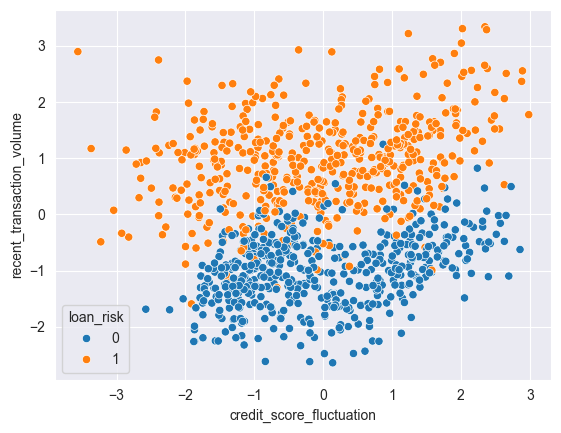

In [55]:
sns.scatterplot(x=data["credit_score_fluctuation"], y=data["recent_transaction_volume"], hue=data["loan_risk"])
plt.show()

In [57]:
X = data.drop("loan_risk", axis=1)
y = data["loan_risk"]

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [59]:
linear = SVC(kernel="linear")
linear.fit(X_train, y_train)
y_pred3 = linear.predict(X_test)

print(classification_report(y_pred3, y_test))
print(confusion_matrix(y_pred3, y_test))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       118
           1       0.93      0.91      0.92       132

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[109   9]
 [ 12 120]]


In [60]:
rbf = SVC(kernel="rbf")
rbf.fit(X_train, y_train)
y_pred4 = rbf.predict(X_test)

print(classification_report(y_pred4, y_test))
print(confusion_matrix(y_pred4, y_test))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       124
           1       0.91      0.94      0.93       126

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[113  11]
 [  8 118]]


In [71]:
poly = SVC(kernel="poly")
poly.fit(X_train, y_train)
y_pred5 = poly.predict(X_test)

print(classification_report(y_pred5, y_test))
print(confusion_matrix(y_pred5, y_test))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       115
           1       0.94      0.90      0.92       135

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

[[107   8]
 [ 14 121]]


In [72]:
sigmoid = SVC(kernel="sigmoid")
sigmoid.fit(X_train, y_train)
y_pred6 = sigmoid.predict(X_test)

print(classification_report(y_pred6, y_test))
print(confusion_matrix(y_pred6, y_test))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       118
           1       0.84      0.83      0.84       132

    accuracy                           0.83       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.83      0.83      0.83       250

[[ 98  20]
 [ 23 109]]


In [73]:
#hyperparemeter tuning

In [74]:
#https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
SVC()

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [75]:
param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "kernel": ["rbf"], #why rbf? because, It was decided that RBF was the best among our previous SVC models.
    "gamma": ["scale", "auto"]
}

In [76]:
from sklearn.model_selection import GridSearchCV

In [77]:
grid = GridSearchCV(estimator=SVC(), param_grid=param_grid, cv=5)
grid.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [78]:
grid.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

In [79]:
y_pred7 = grid.predict(X_test)

print(classification_report(y_pred7, y_test))
print(confusion_matrix(y_pred7, y_test))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92       122
           1       0.92      0.93      0.93       128

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[112  10]
 [  9 119]]
